# Regresión No Lineal y el Peligro de la Extrapolación

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/06_regresion_no_lineal_y_extrapolacion.ipynb)


## Objetivos


- Aplicar algoritmos no lineales (Árboles de Decisión y SVM) a problemas de regresión continua.
- Comprender cómo estos modelos capturan relaciones complejas (como curvas asintóticas) sin necesidad de ingeniería de características manual.
- Demostrar visual y matemáticamente la incapacidad absoluta de los modelos basados en árboles para extrapolar valores fuera del rango de entrenamiento.



## Prerrequisitos


- Entendimiento de la Regresión Lineal y sus limitaciones.
- Haber completado: [Regresión Lineal y Regularización](05_regresion_lineal_y_regularizacion.ipynb).

---



## Configuración del Entorno


In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica



En el notebook anterior, usamos una Regresión Lineal para predecir la resistencia del hormigón. El modelo asumió que si la edad de curado aumenta, la resistencia aumenta infinitamente siguiendo una línea recta.

Cualquier ingeniero civil sabe que esto es falso. El hormigón gana mucha resistencia en los primeros 28 días, pero luego la curva se aplana (comportamiento asintótico). Una línea recta jamás podrá modelar esto correctamente.

Necesitamos modelos que puedan doblarse y adaptarse a la forma real de los datos: **Modelos de Regresión No Lineal**.



### 1. Support Vector Regression (SVR)


La versión de regresión de SVM. En lugar de buscar un hiperplano que separe clases, SVR busca un "tubo" (de ancho $\epsilon$) que envuelva a la mayor cantidad de puntos posibles. Los puntos que quedan fuera del tubo son los que el modelo intenta minimizar. Al usar un Kernel RBF, este tubo puede curvarse libremente en el espacio.



### 2. Decision Tree Regressor


La versión continua de los Árboles de Decisión. En lugar de predecir la clase mayoritaria en una hoja, **predice el valor promedio** de todos los puntos de entrenamiento que cayeron en esa hoja. Esto genera una predicción en forma de "escalones".

De forma visual, estos modelos operarían según se indica en la figura:

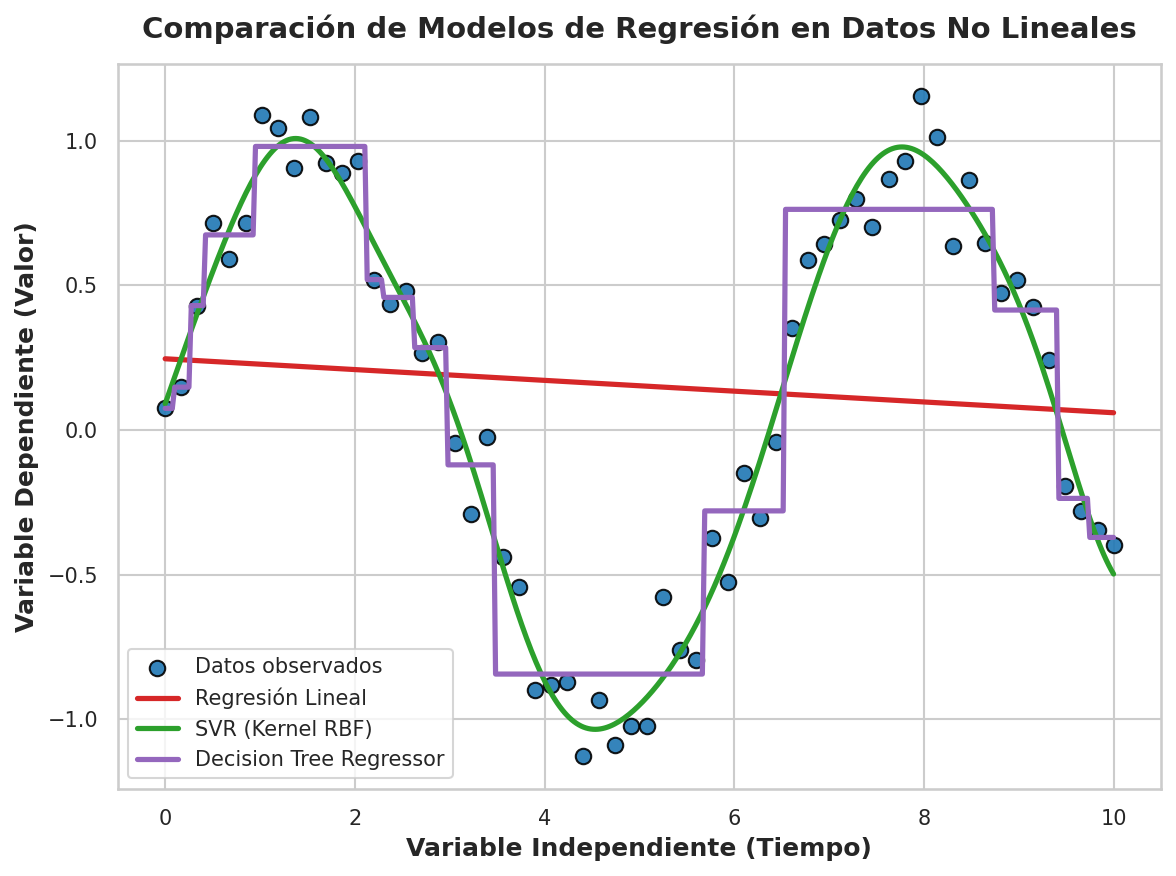

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# -----------------------------
# Generación de datos no lineales
# -----------------------------
np.random.seed(42)

X = np.linspace(0, 10, 60)
y = np.sin(X) + np.random.normal(0, 0.15, size=X.shape)

X = X.reshape(-1, 1)

# Malla suave para curvas
X_plot = np.linspace(0, 10, 400).reshape(-1, 1)

# -----------------------------
# Entrenar modelos
# -----------------------------
lin_model = LinearRegression()
lin_model.fit(X, y)

svr_model = SVR(kernel="rbf", C=100, gamma=0.5, epsilon=0.1)
svr_model.fit(X, y)

tree_model = DecisionTreeRegressor(max_depth=4)
tree_model.fit(X, y)

# Predicciones
y_lin = lin_model.predict(X_plot)
y_svr = svr_model.predict(X_plot)
y_tree = tree_model.predict(X_plot)

fig, ax = plt.subplots(figsize=(8,6))

# Datos reales
ax.scatter(
    X,
    y,
    color="#1f77b4",
    edgecolor="black",
    s=55,
    alpha=0.9,
    label="Datos observados"
)

# Regresión lineal (línea torpe)
ax.plot(
    X_plot,
    y_lin,
    color="#d62728",
    linewidth=2.5,
    label="Regresión Lineal"
)

# SVR (curva suave)
ax.plot(
    X_plot,
    y_svr,
    color="#2ca02c",
    linewidth=2.5,
    label="SVR (Kernel RBF)"
)

# Árbol de decisión (escalones)
ax.plot(
    X_plot,
    y_tree,
    color="#9467bd",
    linewidth=2.5,
    label="Decision Tree Regressor"
)

# -----------------------------
# Etiquetas y formato
# -----------------------------
ax.set_title(
    "Comparación de Modelos de Regresión en Datos No Lineales",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Variable Independiente (Tiempo)", fontsize=12)
ax.set_ylabel("Variable Dependiente (Valor)", fontsize=12)

ax.legend(frameon=True, fontsize=10)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

## Desarrollo e Implementación



Vamos a retomar nuestro **Concrete Compressive Strength Dataset (CCS)**, pero esta vez usamos modelos no lineales para ver si logramos reducir el error (RMSE) de $\sim 10.4$ MPa que obtuvimos con la Regresión Lineal.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Carga de datos
dataset_path = "datasets/ccs/datos_ccs.csv"
df = load_dataset(dataset_path)

X = df.drop(columns=['csMPa'])
y = df['csMPa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Escalado (Crucial para SVR, irrelevante para Árboles, pero lo aplicamos a todo por simplicidad)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Entrenamos los modelos no lineales
# SVR con Kernel RBF (curvo)
modelo_svr = SVR(kernel='rbf', C=100, gamma=0.1)
modelo_svr.fit(X_train_scaled, y_train)

# Árbol de Decisión (escalonado)
modelo_arbol = DecisionTreeRegressor(max_depth=10, random_state=42)
modelo_arbol.fit(X_train_scaled, y_train)

# 4. Evaluamos
y_pred_svr = modelo_svr.predict(X_test_scaled)
y_pred_arbol = modelo_arbol.predict(X_test_scaled)

print(f"SVR (Kernel RBF) - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_svr)):.2f} MPa | R2: {r2_score(y_test, y_pred_svr):.3f}")
print(f"Árbol de Decisión - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_arbol)):.2f} MPa | R2: {r2_score(y_test, y_pred_arbol):.3f}")

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/ccs/datos_ccs.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 1030 filas y 9 columnas.
SVR (Kernel RBF) - RMSE: 5.80 MPa | R2: 0.870
Árbol de Decisión - RMSE: 6.72 MPa | R2: 0.825



¡Impresionante! Hemos bajado el error de $\sim 10.4$ MPa a $\sim 5.8$ MPa (SVR) y $\sim 6.7$ MPa (Árbol). El R2 saltó del 62% a más del 80%. Los modelos no lineales capturaron la verdadera física de la mezcla de hormigón.

Pero, como ingenieros, no podemos quedarnos solo con las métricas de laboratorio. Debemos preguntarnos: **¿Qué pasa cuando el modelo se enfrenta a lo desconocido?**



### ⚠️ El Peligro de la Extrapolación



Imaginemos que la empresa nos pide predecir las ventas del próximo año,basándose en la tendencia histórica. O predecir la resistencia de un hormigón curado durante 500 días (cuando el dataset solo llega hasta 365 días).

A esto se le llama **Extrapolar**: pedirle al modelo que prediga valores fuera del rango numérico que vio durante el entrenamiento.

Vamos a simular este escenario con un dataset sintético muy simple: una tendencia lineal ascendente. Entrenamos los modelos con datos del año 2000 al 2020, y les pedimos que predigan hasta el año 2030.



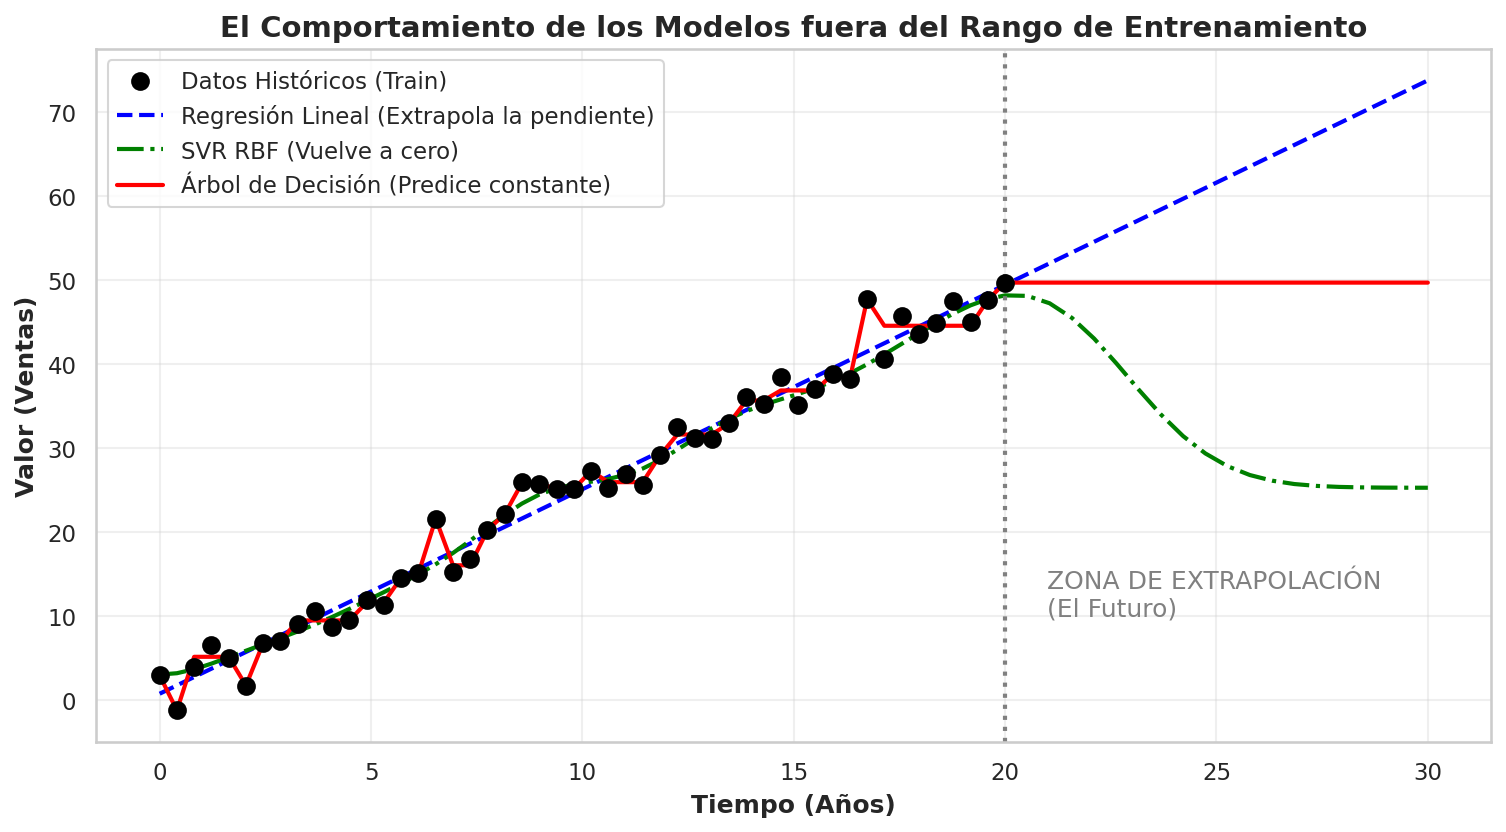

In [ ]:
# 1. Generamos datos sintéticos de tendencia (ej. Ventas a lo largo del tiempo)
# Datos de entrenamiento (Años 0 a 20)
X_tiempo_train = np.linspace(0, 20, 50).reshape(-1, 1)
y_tendencia_train = 2.5 * X_tiempo_train.ravel() + np.random.normal(0, 2, 50) # Línea recta con ruido

# Datos de extrapolación (Años 20 a 30) - El futuro desconocido
X_tiempo_futuro = np.linspace(20, 30, 20).reshape(-1, 1)

# 2. Entrenamos tres modelos diferentes
from sklearn.linear_model import LinearRegression

reg_lineal = LinearRegression().fit(X_tiempo_train, y_tendencia_train)
reg_svr = SVR(kernel='rbf', C=100, gamma=0.1).fit(X_tiempo_train, y_tendencia_train)
reg_arbol = DecisionTreeRegressor(max_depth=5).fit(X_tiempo_train, y_tendencia_train)

# 3. Predecimos el pasado (interpolación) y el futuro (extrapolación)
X_total = np.vstack((X_tiempo_train, X_tiempo_futuro))

pred_lineal = reg_lineal.predict(X_total)
pred_svr = reg_svr.predict(X_total)
pred_arbol = reg_arbol.predict(X_total)

# 4. Visualizamos el desastre
plt.figure(figsize=(12, 6))

# Datos reales (Entrenamiento)
plt.scatter(X_tiempo_train, y_tendencia_train, color='black', label='Datos Históricos (Train)', zorder=5)

# Predicciones
plt.plot(X_total, pred_lineal, color='blue', linestyle='--', linewidth=2, label='Regresión Lineal (Extrapola la pendiente)')
plt.plot(X_total, pred_svr, color='green', linestyle='-.', linewidth=2, label='SVR RBF (Vuelve a cero)')
plt.plot(X_total, pred_arbol, color='red', linewidth=2, label='Árbol de Decisión (Predice constante)')

# Marcamos la frontera de lo desconocido
plt.axvline(x=20, color='gray', linestyle=':', linewidth=2)
plt.text(21, 10, 'ZONA DE EXTRAPOLACIÓN\n(El Futuro)', fontsize=12, color='gray')

plt.title("El Comportamiento de los Modelos fuera del Rango de Entrenamiento", fontsize=14)
plt.xlabel("Tiempo (Años)")
plt.ylabel("Valor (Ventas)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

## Resultados y Discusión



Observar detenidamente la "Zona de Extrapolación" (a la derecha de la línea punteada). Este gráfico ilustra uno de los errores más costosos que se pueden cometer en Machine Learning:

1. **La Regresión Lineal (Azul):** Entiende la matemática de la pendiente ($y = mx + b$). Por lo tanto, continúa proyectando la tendencia hacia el infinito de manera lógica.
2. **El Árbol de Decisión (Rojo):** ¡Predice una línea plana horizontal! ¿Por qué? Recuerdemos cómo funciona: el árbol hace preguntas. Su última pregunta fue *"¿El año es mayor a 19?"*. Todos los años futuros (21, 25, 30) caen en esa misma hoja final. Y la regla del árbol es predecir el promedio de los datos de entrenamiento que cayeron en esa hoja. **Un árbol jamás podrá predecir un número mayor al máximo número que vio en el entrenamiento.**
3. **SVR con Kernel RBF (Verde):** ¡Se desploma hacia cero! El Kernel RBF mide la similitud (distancia) entre el punto nuevo y los datos de entrenamiento. A medida que nos alejamos hacia el futuro, la similitud con el pasado cae a cero, y el modelo asume que el valor también debe ser cero.

**Conclusión de Ingeniería:**

Si el problema requiere proyectar tendencias futuras (Series de Tiempo, proyecciones financieras, desgaste de materiales a largo plazo), **jamás utilizar Árboles de Decisión, Random Forest o XGBoost de forma directa**. Se deben usar modelos lineales, modelos estadísticos (ARIMA) o Redes Neuronales Recurrentes, o bien, extraer la tendencia lineal primero y usar el árbol solo para predecir los residuos (el ruido). Entender el problema es crucial, y luego... en base a las limitaciones de los modelos, escoger el adecuado.



## Conexiones y Próximos Pasos



Hemos visto que los modelos no lineales son increíblemente potentes para interpolar (predecir dentro del rango conocido), pero requieren un ajuste cuidadoso de sus hiperparámetros (como la profundidad del árbol o el valor `C` y `gamma` en SVR) para no sobreajustar.

- ➡️ **Siguiente:** En el notebook [Optimización de Hiperparámetros](07_optimizacion_hiperparametros_y_cv.ipynb), dejamos de adivinar estos valores. Aprenderemos a sistematizar la búsqueda de la configuración óptima utilizando Validación Cruzada y algoritmos de búsqueda (Grid y Random Search).
- 🔄 **Relacionado:** Si te interesa cómo combinar la capacidad de extrapolación de los modelos lineales con la flexibilidad de los árboles, investigar sobre los *Modelos Aditivos Generalizados (GAMs)*.



## Referencias


1. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. (Capítulo 9: Additive Trees and Related Methods).
2. [Scikit-Learn: Support Vector Regression](https://scikit-learn.org/stable/modules/svm.html#svm-regression)

---


## Entorno de Ejecución


In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
